<h1> Задание по Uplift-моделированию </h1>

## Импорты

In [1]:
!pip install scikit-uplift
# !pip install causalml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import Pipeline
from sklearn.utils import compute_class_weight

from sklift.models import ClassTransformation
from sklift.models import SoloModel, TwoModels
from sklift.metrics import qini_auc_score
from sklift.viz import plot_qini_curve

# from causalml.inference.tree import UpliftRandomForestClassifier

In [3]:
# def plot_qini_curve(y_true, uplift, treatment, name=""):
#     df = pd.DataFrame({
#         'y_true': pd.Series(y_true).astype(int),
#         'uplift': uplift,
#         't_flag': pd.Series(treatment).astype(int)
#     })
#     df_sort = df.sort_values('uplift', ascending=False).reset_index(drop=True)
#     cum_treat = (df_sort['y_true'] * (df_sort['t_flag'] == 1)).cumsum()
#     cum_control = (df_sort['y_true'] * (df_sort['t_flag'] == 0)).cumsum()
#     lift = cum_treat - cum_control
#     random_line = [0] * len(lift)
#     df_opt = df.copy()
#     df_opt['sorter'] = (df_opt['t_flag'] == 1) & (df_opt['y_true'] == 1)
#     df_opt = df_opt.sort_values('sorter', ascending=False).reset_index(drop=True)
#     cum_treat_opt = (df_opt['y_true'] * (df_opt['t_flag'] == 1)).cumsum()
#     cum_control_opt = (df_opt['y_true'] * (df_opt['t_flag'] == 0)).cumsum()
#     lift_opt = cum_treat_opt - cum_control_opt
#     plt.plot(lift, label='Qini (модель)', lw=2)
#     plt.plot(lift_opt, label='Идеальное предсказание', lw=2, color='green')
#     plt.plot(random_line, '--', color='grey', label='Рандом')
#     plt.xlabel('Количество клиентов (отсортировано по uplift)')
#     plt.ylabel('Кумулятивный uplift')
#     plt.title(name)
#     plt.legend()


## Введение

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>

1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов

2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента

3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).

4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [4]:
!pip install gdown -q

In [5]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=71ca4f73-1409-46e9-b902-f3d85403f238
To: /kaggle/working/Data.zip
100%|██████████| 289M/289M [00:03<00:00, 81.7MB/s] 


'Data.zip'

In [6]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/')

In [7]:
!mv /kaggle/working/'ДЗ по Uplift обновленное' /kaggle/working/hw

## Описание данных

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

# Декомпозиция задачи

## 1.	Сбор и анализ таргета (18 баллов)

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должна появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [8]:
data_path = "hw"
feats = pd.read_csv(f"{data_path}/AGGS_FINAL.csv").iloc[:, 1:]
camps = pd.read_csv(f"{data_path}/CAMPAINGS.csv").iloc[:, 1:]
conts = pd.read_csv(f"{data_path}/CONTRACTS_FINAL.csv").iloc[:, 1:]
p_camps = pd.read_csv(f"{data_path}/PEOPLE_IN_CAMPAINGS_FINAL.csv").iloc[:, 1:]

In [9]:
feats.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow


In [10]:
camps

,campaing_id,product_id,channel
0,iddqd,1,push
1,idclip,1,sms
2,iddt,1,banner
3,idkfa,1,other_ads


In [11]:
conts.head()

,user_id,contract_date,product_id,contract_id
0,4008279,2024-11-03,1,0001_2024-11-03_4008279
1,2079035,2024-11-08,1,0001_2024-11-08_2079035
2,103088,2024-11-13,1,0001_2024-11-13_103088
3,2026788,2024-11-02,1,0001_2024-11-02_2026788
4,52269,2024-11-17,1,0001_2024-11-17_52269


In [12]:
p_camps.head()

,campaing_id,user_id,t_flag,delivery_date
0,idclip,1099975,1,2024-11-06
1,iddqd,1162,1,2024-11-08
2,iddqd,42991,1,2024-11-07
3,idclip,142343,0,unknown
4,iddqd,24623,0,unknown


### Собираем таргет

In [13]:
def make_target(x_group, max_target):
  x_target = x_group.merge(conts, on="user_id", how="left")[["user_id", "delivery_date", "contract_date"]]
  x_target["delivery_date"] = x_target["delivery_date"].replace({"unknown": "2024-11-1"})
  x_target["delivery_date"] = pd.to_datetime(x_target["delivery_date"])
  x_target["contract_date"] = pd.to_datetime(x_target["contract_date"])
  x_target["contract_date"] = x_target["contract_date"].fillna(pd.Timestamp('2026-01-01'))
  x_target["diff"] = (x_target["contract_date"] - x_target["delivery_date"]).dt.days
  x_target["report_dt"] = x_target["delivery_date"]
  # - pd.Timedelta(days=60)
  x_target["target"] = ((x_target["diff"] <= max_target) & (x_target["diff"] >= 0)).astype(int)
  return x_target[["user_id", "report_dt", "target"]], x_target.loc[x_target["diff"] < 300, "diff"].values

In [14]:
# push
p_group_a = p_camps[(p_camps["campaing_id"] == "iddqd") & (p_camps["t_flag"] == 0)]
p_group_b = p_camps[(p_camps["campaing_id"] == "iddqd") & (p_camps["t_flag"] == 1)]
# sms
s_group_a = p_camps[(p_camps["campaing_id"] == "idclip") & (p_camps["t_flag"] == 0)]
s_group_b = p_camps[(p_camps["campaing_id"] == "idclip") & (p_camps["t_flag"] == 1)]
# banner
b_group_a = p_camps[(p_camps["campaing_id"] == "iddt") & (p_camps["t_flag"] == 0)]
b_group_b = p_camps[(p_camps["campaing_id"] == "iddt") & (p_camps["t_flag"] == 1)]
# other_ads
oa_group_a = p_camps[(p_camps["campaing_id"] == "idkfa") & (p_camps["t_flag"] == 0)]
oa_group_b = p_camps[(p_camps["campaing_id"] == "idkfa") & (p_camps["t_flag"] == 1)]

In [15]:
# push
p_target_a, _ = make_target(p_group_a, 21)
p_target_b, p_diff_b = make_target(p_group_b, 14)
# sms
s_target_a, _ = make_target(s_group_a, 21)
s_target_b, s_diff_b = make_target(s_group_b, 14)
# banner
b_target_a, _ = make_target(b_group_a, 21)
b_target_b, b_diff_b = make_target(b_group_b, 14)
# other_ads
oa_target_a, _ = make_target(oa_group_a, 21)
oa_target_b, oa_diff_b = make_target(oa_group_b, 14)

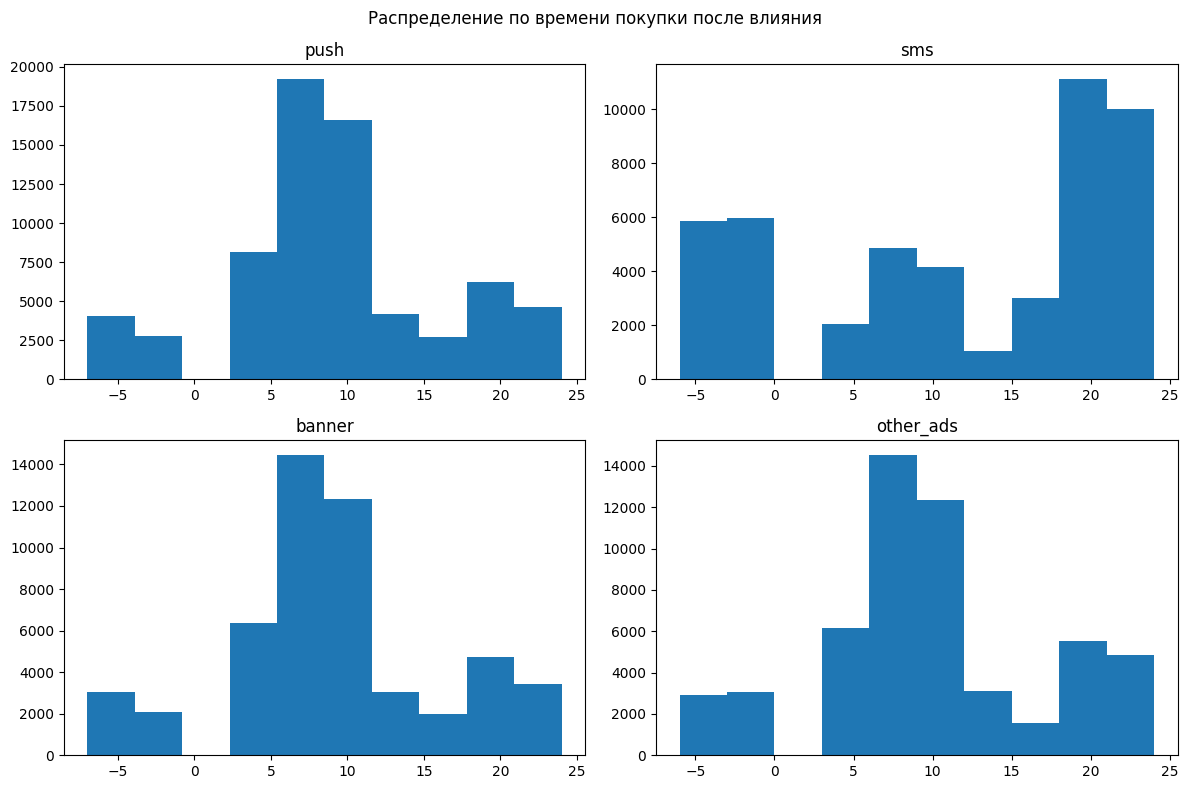

In [16]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.hist(p_diff_b)
plt.title("push")
plt.subplot(2,2,2)
plt.hist(s_diff_b)
plt.title("sms")
plt.subplot(2,2,3)
plt.hist(b_diff_b)
plt.title("banner")
plt.subplot(2,2,4)
plt.hist(oa_diff_b)
plt.title("other_ads")
plt.suptitle("Распределение по времени покупки после влияния")

plt.tight_layout()

In [17]:
p_uplift = round(p_target_b["target"].mean() - p_target_a["target"].mean(), 2)
s_uplift = round(s_target_b["target"].mean() - s_target_a["target"].mean(), 2)
b_uplift = round(b_target_b["target"].mean() - b_target_a["target"].mean(), 2)
oa_uplift = round(oa_target_b["target"].mean() - oa_target_a["target"].mean(), 2)

uplift_df = pd.DataFrame({"campaing" : ["push", "sms", "banner", "other_ads"],
                               "uplift": [p_uplift, s_uplift, b_uplift, oa_uplift]})
uplift_df

,campaing,uplift
0,push,0.40
1,sms,-0.48
2,banner,0.20
3,other_ads,0.20


По проведенному анализу можем видеть, что коммуникация `sms` приводит к негативному отклику у пользователей, поэтому по ней мы не будем строить uplift модель

## 2. Клиентские агрегаты (12 баллов)

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должны сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

### Добавление фичей

In [18]:
feats["report_dt"] = pd.to_datetime(feats["report_dt"])
sort_feats = feats.sort_values(["user_id", "report_dt"])

In [19]:
def make_features(target_df):
  x_feats = target_df.sort_values(["user_id", "report_dt"])
  x_feats = x_feats.merge(sort_feats, on="user_id", how="left")
  x_feats = x_feats[x_feats["report_dt_x"] >= x_feats["report_dt_y"]].drop_duplicates(subset=["user_id", "report_dt_x"], keep="first").rename(columns={"report_dt_y": "report_dt"})
  return x_feats[["user_id", "report_dt", "age", "city"] + [col for col in x_feats.columns if ("x" in col) and ("_" not in col)] + ["target"]]

In [20]:
# push
p_feats_a = make_features(p_target_a)
p_feats_b = make_features(p_target_b)
# banner
b_feats_a = make_features(b_target_a)
b_feats_b = make_features(b_target_b)
# other_ads
oa_feats_a = make_features(oa_target_a)
oa_feats_b = make_features(oa_target_b)

In [21]:
# проверим, что ничего не потеряли
assert p_feats_a.shape[0] == p_target_a.shape[0]
assert p_feats_b.shape[0] == p_target_b.shape[0]
assert b_feats_a.shape[0] == b_target_a.shape[0]
assert b_feats_b.shape[0] == b_target_b.shape[0]
assert oa_feats_a.shape[0] == oa_target_a.shape[0]
assert oa_feats_b.shape[0] == oa_target_b.shape[0]

### EDA

#### push

In [22]:
# Однородность данных
mean_sim = pd.concat([p_feats_a.select_dtypes(np.number).mean(), p_feats_b.select_dtypes(np.number).mean()], axis=1).iloc[1:-1]
mean_sim

,0,1
age,32.504013,32.448462
x1,0.604476,0.601202
x2,0.991262,1.004994
x3,0.989826,0.996935
x4,-0.606210,-0.596487
x5,0.592924,0.601505
x6,-0.002248,-0.002147
x7,-0.002248,-0.004232
x8,-0.000358,-0.003318
x9,0.524898,0.523636


In [23]:
# Однородность данных
med_sim = pd.concat([p_feats_a.select_dtypes(np.number).median(), p_feats_b.select_dtypes(np.number).median()], axis=1).iloc[1:-1]
med_sim

,0,1
age,32.000000,32.000000
x1,0.690167,0.684945
x2,0.991941,1.003702
x3,0.991280,0.994629
x4,-0.698398,-0.683922
x5,0.715804,0.723315
x6,0.000645,-0.003707
x7,-0.208016,-0.208410
x8,-0.561839,-0.561366
x9,0.575092,0.573658


In [24]:
feats_name = med_sim.index

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

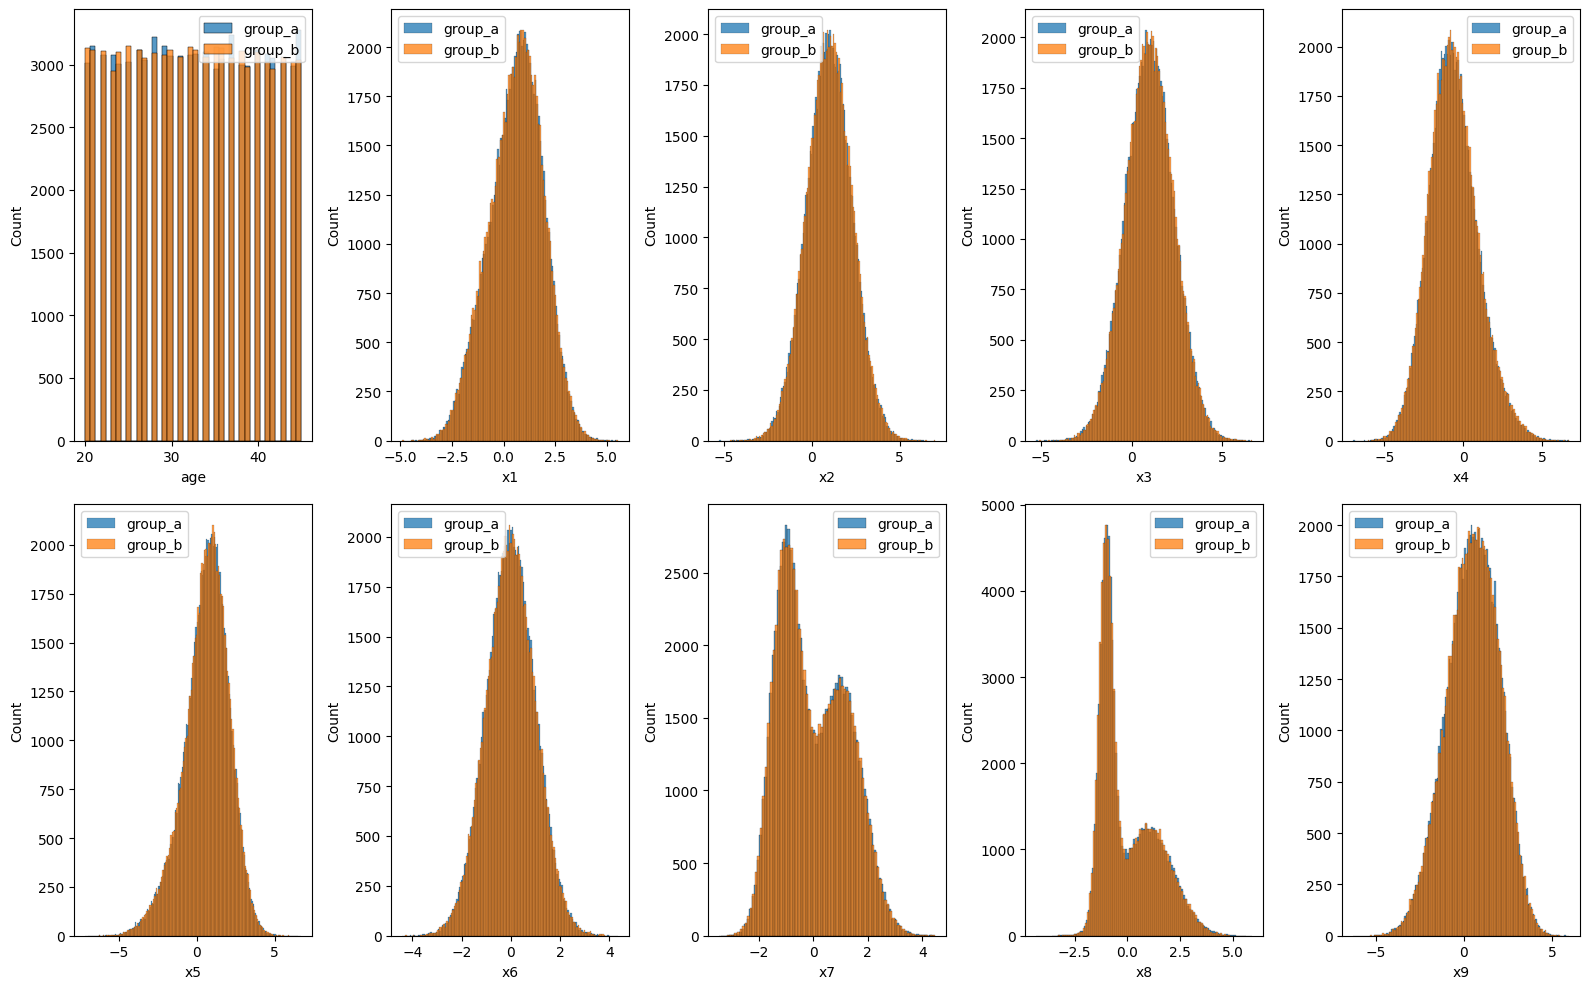

In [25]:
plt.figure(figsize=(16, 10))

for i in range(len(feats_name)):
  plt.subplot(2, 5, i+1)
  sns.histplot(data = p_feats_a, x=feats_name[i], label="group_a")
  sns.histplot(data = p_feats_b, x=feats_name[i], label="group_b")
  plt.legend()

plt.tight_layout()

#### banner

In [26]:
# Однородность данных
mean_sim = pd.concat([b_feats_a.select_dtypes(np.number).mean(), b_feats_b.select_dtypes(np.number).mean()], axis=1).iloc[1:-1]
mean_sim

,0,1
age,32.531317,32.500350
x1,-0.200788,-0.190153
x2,-1.005438,-0.996064
x3,0.195224,0.201646
x4,-0.201540,-0.199495
x5,0.005851,-0.003222
x6,-0.000878,0.002184
x7,0.335597,0.335707
x8,0.333879,0.332511
x9,-0.231895,-0.234196


In [27]:
# Однородность данных
med_sim = pd.concat([b_feats_a.select_dtypes(np.number).median(), b_feats_b.select_dtypes(np.number).median()], axis=1).iloc[1:-1]
med_sim

,0,1
age,33.000000,33.000000
x1,-0.039344,-0.029260
x2,-1.000710,-0.992088
x3,0.151140,0.163890
x4,-0.191527,-0.182136
x5,0.004826,-0.004370
x6,0.001446,0.006098
x7,0.520809,0.513940
x8,0.712336,0.719739
x9,-0.245529,-0.246031


In [28]:
feats_name = med_sim.index

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

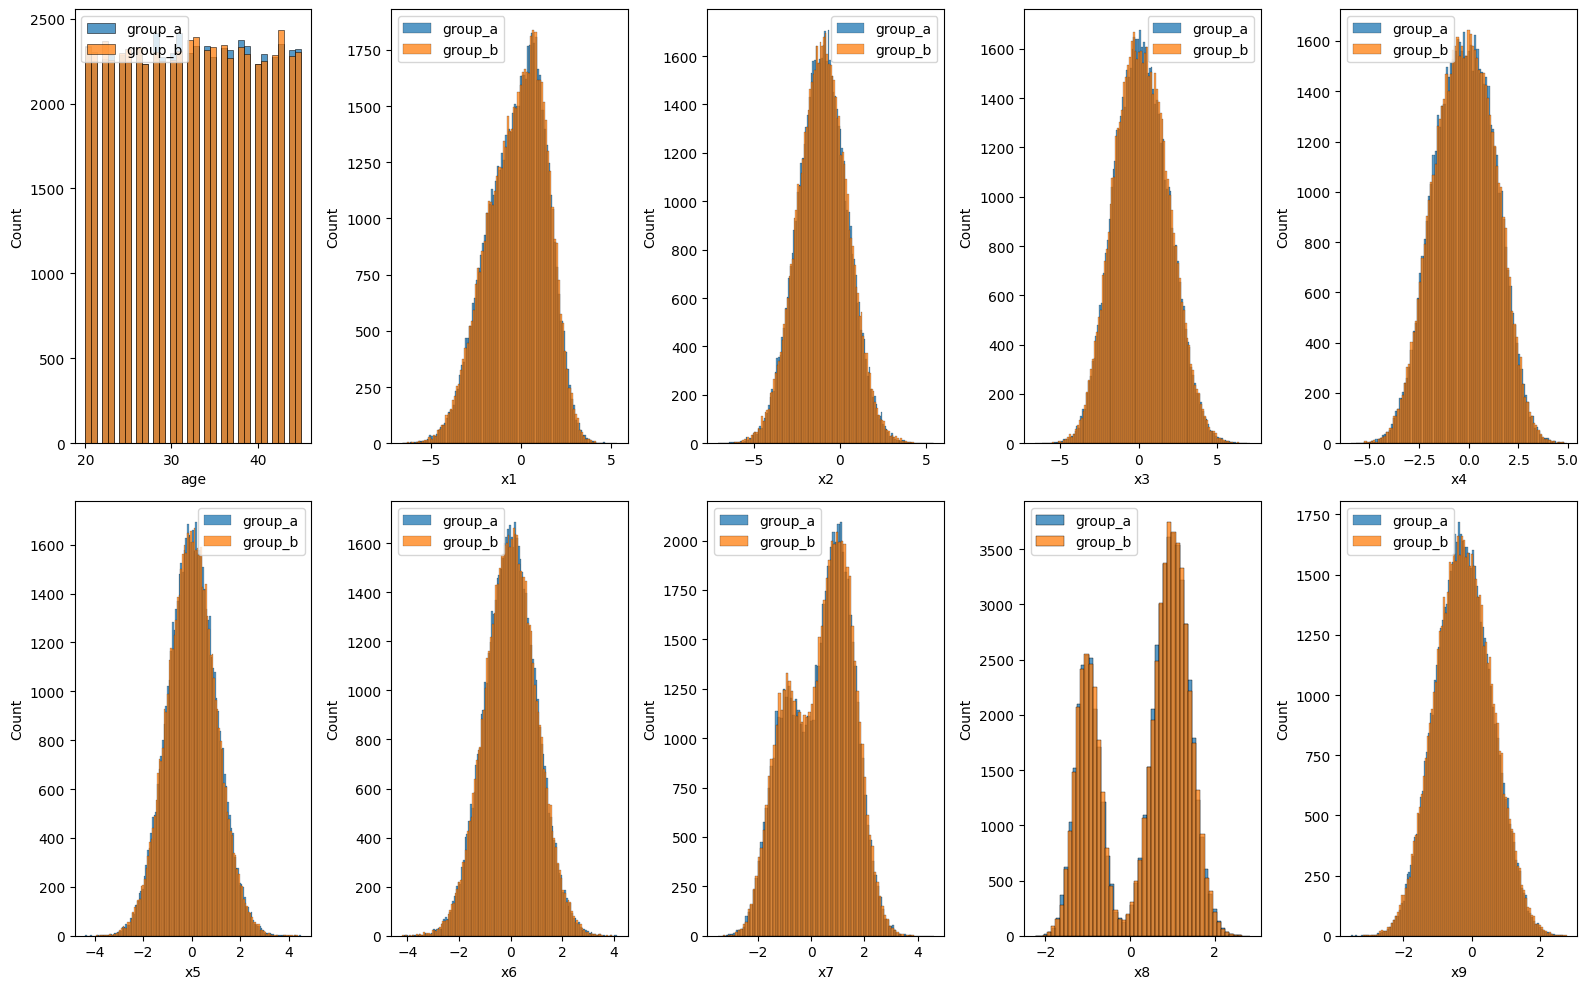

In [29]:
plt.figure(figsize=(16, 10))

for i in range(len(feats_name)):
  plt.subplot(2, 5, i+1)
  sns.histplot(data = b_feats_a, x=feats_name[i], label="group_a")
  sns.histplot(data = b_feats_b, x=feats_name[i], label="group_b")
  plt.legend()

plt.tight_layout()

#### other_ads

In [30]:
# Однородность данных
mean_sim = pd.concat([oa_feats_a.select_dtypes(np.number).mean(), oa_feats_b.select_dtypes(np.number).mean()], axis=1).iloc[1:-1]
mean_sim

,0,1
age,32.565050,32.494200
x1,-0.200788,-0.190153
x2,-1.005438,-0.996064
x3,0.195224,0.201646
x4,-0.201540,-0.199495
x5,0.000000,-0.003222
x6,-0.000878,0.002184
x7,0.335597,0.335707
x8,0.333879,0.332511
x9,-0.231895,-0.234196


In [31]:
# Однородность данных
med_sim = pd.concat([oa_feats_a.select_dtypes(np.number).median(), oa_feats_b.select_dtypes(np.number).median()], axis=1).iloc[1:-1]
med_sim

,0,1
age,33.000000,32.000000
x1,-0.039344,-0.029260
x2,-1.000710,-0.992088
x3,0.151140,0.163890
x4,-0.191527,-0.182136
x5,0.000000,-0.004370
x6,0.001446,0.006098
x7,0.520809,0.513940
x8,0.712336,0.719739
x9,-0.245529,-0.246031


In [32]:
feats_name = med_sim.index

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

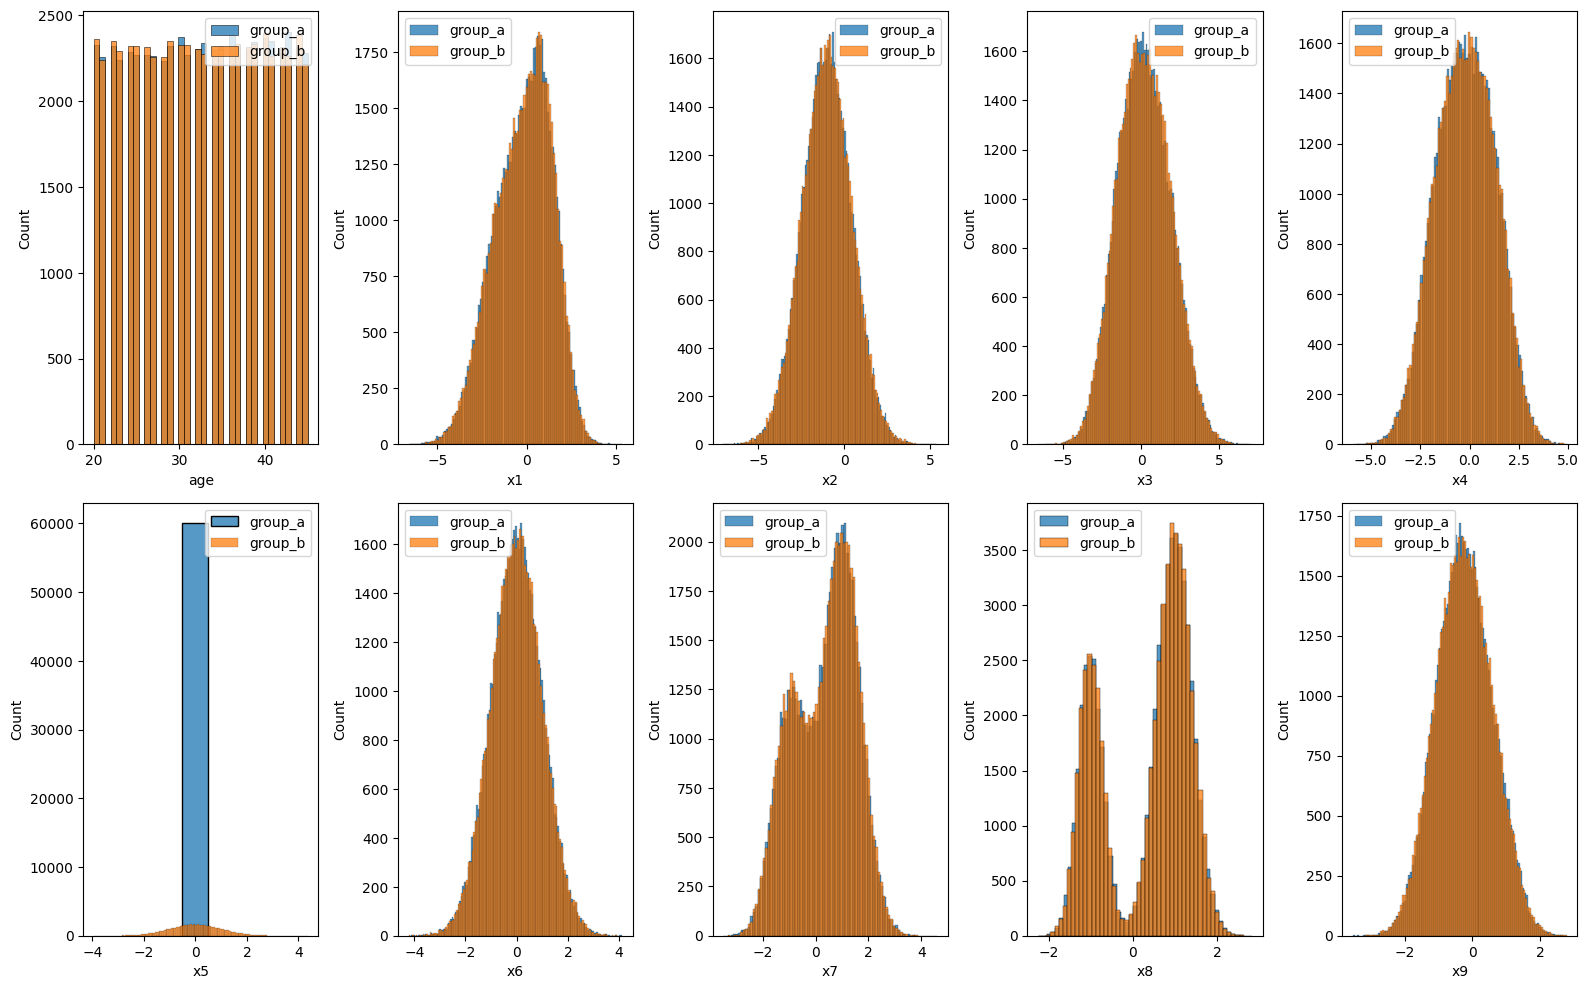

In [33]:
plt.figure(figsize=(16, 10))

for i in range(len(feats_name)):
  plt.subplot(2, 5, i+1)
  sns.histplot(data = oa_feats_a, x=feats_name[i], label="group_a")
  sns.histplot(data = oa_feats_b, x=feats_name[i], label="group_b")
  plt.legend()

plt.tight_layout()

### Вывод

Ранее поняли, что по коммукации `sms` наблюдается негативный uplift, поэтому по этой кампании модель строить не будем, остальные данные получились довольно-таки однородными, кроме фичи `x5` в комункации `other_ads`: в контрольной группе она равна `0`, поэтому либо будем удалять эту фичу, либо просто не буедм строить модель по этой коммуникации

## 3. Построение моделей и оценка их качества (14 баллов)

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

### Split data

In [34]:
feats_name = med_sim.index
feats_name

Index(['age', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9'], dtype='object')

In [35]:
# push
p_feats_a["t_flag"] = 0
p_feats_b["t_flag"] = 1
# banner
b_feats_a["t_flag"] = 0
b_feats_b["t_flag"] = 1
# other_ads
oa_feats_a["t_flag"] = 0
oa_feats_b["t_flag"] = 1

In [36]:
p_feats = pd.concat([p_feats_a, p_feats_b])
b_feats = pd.concat([b_feats_a, b_feats_b])
oa_feats = pd.concat([oa_feats_a, oa_feats_b])

In [37]:
p_X, p_y, p_treat = p_feats[feats_name], p_feats["target"], p_feats["t_flag"]
b_X, b_y, b_treat = b_feats[feats_name], b_feats["target"], b_feats["t_flag"]
oa_X, oa_y, oa_treat = oa_feats[feats_name], oa_feats["target"], oa_feats["t_flag"]

In [38]:
p_X_train, p_X_test, p_y_train, p_y_test, p_treat_train, p_treat_test = train_test_split(
    p_X, p_y, p_treat,
    test_size=0.2, stratify=p_y, shuffle=True, random_state=42)
b_X_train, b_X_test, b_y_train, b_y_test, b_treat_train, b_treat_test = train_test_split(
    b_X, b_y, b_treat,
    test_size=0.2, stratify=b_y, shuffle=True, random_state=42)
oa_X_train, oa_X_test, oa_y_train, oa_y_test, oa_treat_train, oa_treat_test = train_test_split(
    oa_X, oa_y, oa_treat,
    test_size=0.2, stratify=oa_y, shuffle=True, random_state=42)

In [39]:
p_X_tr, p_X_val, p_y_tr, p_y_val, p_treat_tr, p_treat_val = train_test_split(
    p_X_train, p_y_train, p_treat_train,
    test_size=0.25, stratify=p_y_train, random_state=42, shuffle=True)

b_X_tr, b_X_val, b_y_tr, b_y_val, b_treat_tr, b_treat_val = train_test_split(
    b_X_train, b_y_train, b_treat_train,
    test_size=0.25, stratify=b_y_train, random_state=42, shuffle=True)

oa_X_tr, oa_X_val, oa_y_tr, oa_y_val, oa_treat_tr, oa_treat_val = train_test_split(
    oa_X_train, oa_y_train, oa_treat_train,
    test_size=0.25, stratify=oa_y_train, random_state=42, shuffle=True)


### SoloModel

In [40]:
# push
p_X_tr_ = p_X_tr.copy()
p_X_tr_["t_flag"] = p_treat_tr
p_X_val_t = p_X_val.copy()
p_X_val_t["t_flag"] = 1
p_X_val_c = p_X_val.copy()
p_X_val_c["t_flag"] = 0

p_sm1 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
p_sm1.fit(p_X_tr_, p_y_tr)
p_sm1_uplift = p_sm1.predict_proba(p_X_val_t)[:, 1] - p_sm1.predict_proba(p_X_val_c)[:, 1]
# banner
b_X_tr_ = b_X_tr.copy()
b_X_tr_["t_flag"] = b_treat_tr
b_X_val_t = b_X_val.copy()
b_X_val_t["t_flag"] = 1
b_X_val_c = b_X_val.copy()
b_X_val_c["t_flag"] = 0

b_sm1 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
b_sm1.fit(b_X_tr_, b_y_tr)
b_sm1_uplift = b_sm1.predict_proba(b_X_val_t)[:, 1] - b_sm1.predict_proba(b_X_val_c)[:, 1]
# other_ads
oa_X_tr_ = oa_X_tr.copy()
oa_X_tr_["t_flag"] = oa_treat_tr
oa_X_val_t = oa_X_val.copy()
oa_X_val_t["t_flag"] = 1
oa_X_val_c = oa_X_val.copy()
oa_X_val_c["t_flag"] = 0

oa_sm1 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
oa_sm1.fit(oa_X_tr_, oa_y_tr)
oa_sm1_uplift = oa_sm1.predict_proba(oa_X_val_t)[:, 1] - oa_sm1.predict_proba(oa_X_val_c)[:, 1]

In [41]:
sm1_uplift = pd.DataFrame({"campaign": ["push", "banner", "other_ads"], "uplift": [p_sm1_uplift.mean(), b_sm1_uplift.mean(), oa_sm1_uplift.mean()]})
sm1_uplift

,campaign,uplift
0,push,0.341743
1,banner,0.129025
2,other_ads,0.104351


In [42]:
p_auc_sm1 = round(qini_auc_score(p_y_val, p_sm1_uplift, p_treat_val), 2)
b_auc_sm1 = round(qini_auc_score(b_y_val, b_sm1_uplift, b_treat_val), 2)
oa_auc_sm1 = round(qini_auc_score(oa_y_val, oa_sm1_uplift, oa_treat_val), 2)

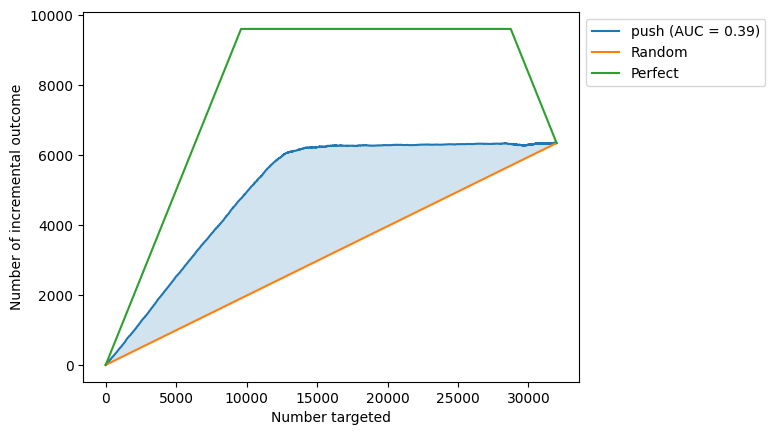

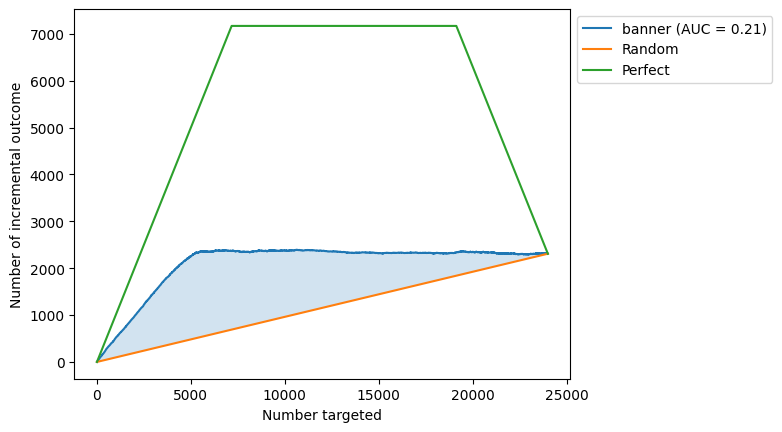

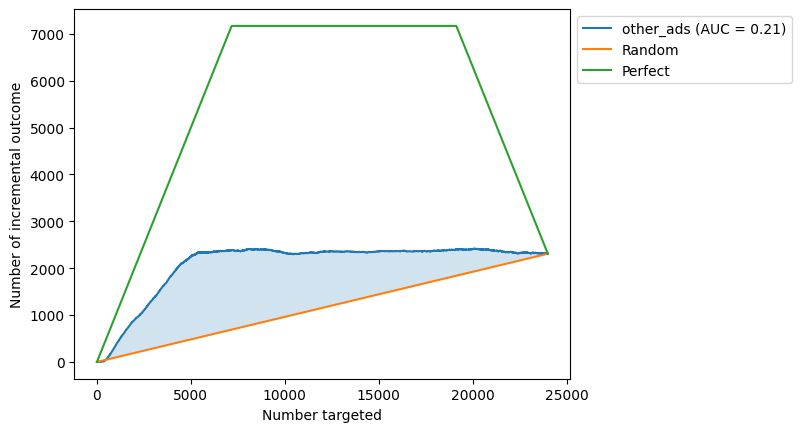

In [43]:
plot_qini_curve(p_y_val, p_sm1_uplift, p_treat_val, name="push")
plot_qini_curve(b_y_val, b_sm1_uplift, b_treat_val, name="banner")
plot_qini_curve(oa_y_val, oa_sm1_uplift, oa_treat_val, name="other_ads")

### SoloModel&TwoModel

In [44]:
# push
p_X_tr_ = p_X_tr.copy()
p_X_val_ = p_X_val.copy()

p_sm2 = SoloModel(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
p_sm2.fit(p_X_tr_, p_y_tr, p_treat_tr)
p_ul_sm2 = p_sm2.predict(p_X_val_)

p_tm1 = TwoModels(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42), 
                  RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
p_tm1.fit(p_X_tr_, p_y_tr, p_treat_tr)
p_ul_tm1 = p_tm1.predict(p_X_val_)
# banner
b_X_tr_ = b_X_tr.copy()
b_X_val_ = b_X_val.copy()

b_sm2 = SoloModel(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
b_sm2.fit(b_X_tr_, b_y_tr, b_treat_tr)
b_ul_sm2 = b_sm2.predict(b_X_val_)

b_tm1 = TwoModels(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42), 
                  RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
b_tm1.fit(b_X_tr_, b_y_tr, b_treat_tr)
b_ul_tm1 = b_tm1.predict(b_X_val_)
# other_ads
oa_X_tr_ = oa_X_tr.copy()
oa_X_val_ = oa_X_val.copy()

oa_sm2 = SoloModel(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
oa_sm2.fit(oa_X_tr_, oa_y_tr, oa_treat_tr)
oa_ul_sm2 = oa_sm2.predict(oa_X_val_)

oa_tm1 = TwoModels(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42), 
                   RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
oa_tm1.fit(oa_X_tr_, oa_y_tr, oa_treat_tr)
oa_ul_tm1 = oa_tm1.predict(oa_X_val_)

In [45]:
sm2_uplift = pd.DataFrame({"campaign": ["push", "banner", "other_ads"], "uplift": [p_ul_sm2.mean(), b_ul_sm2.mean(), oa_ul_sm2.mean()]})
sm2_uplift

,campaign,uplift
0,push,0.341743
1,banner,0.129025
2,other_ads,0.104351


In [46]:
tm1_uplift = pd.DataFrame({"campaign": ["push", "banner", "other_ads"], "uplift": [p_ul_tm1.mean(), b_ul_tm1.mean(), oa_ul_tm1.mean()]})
tm1_uplift

,campaign,uplift
0,push,0.293670
1,banner,0.144005
2,other_ads,0.141859


In [47]:
# sklift solomodel
p_auc_sm2 = round(qini_auc_score(p_y_val, p_ul_sm2, p_treat_val), 2)
b_auc_sm2 = round(qini_auc_score(b_y_val, b_ul_sm2, b_treat_val), 2)
oa_auc_sm2 = round(qini_auc_score(oa_y_val, oa_ul_sm2, oa_treat_val), 2)
# sklift twomodel
p_auc_tm1 = round(qini_auc_score(p_y_val, p_ul_tm1, p_treat_val), 2)
b_auc_tm1 = round(qini_auc_score(b_y_val, b_ul_tm1, b_treat_val), 2)
oa_auc_tm1 = round(qini_auc_score(oa_y_val, oa_ul_tm1, oa_treat_val), 2)

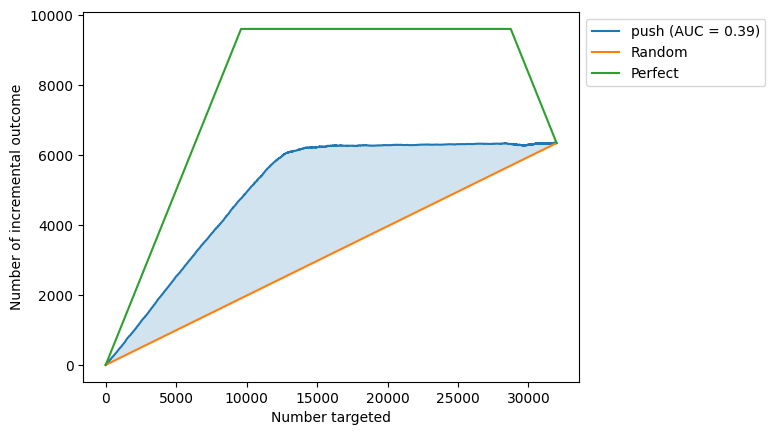

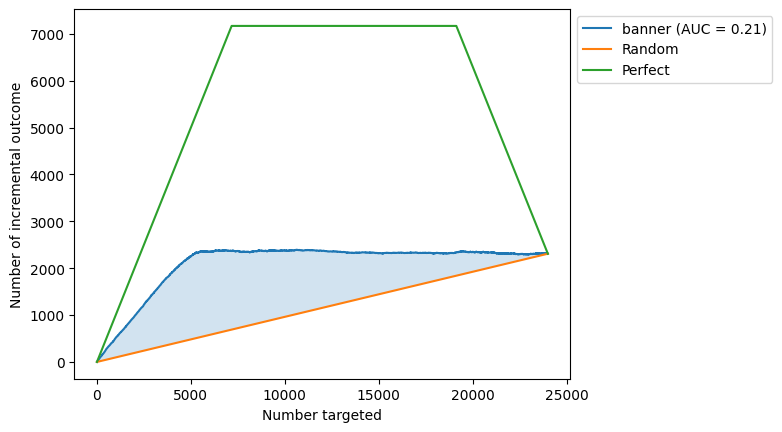

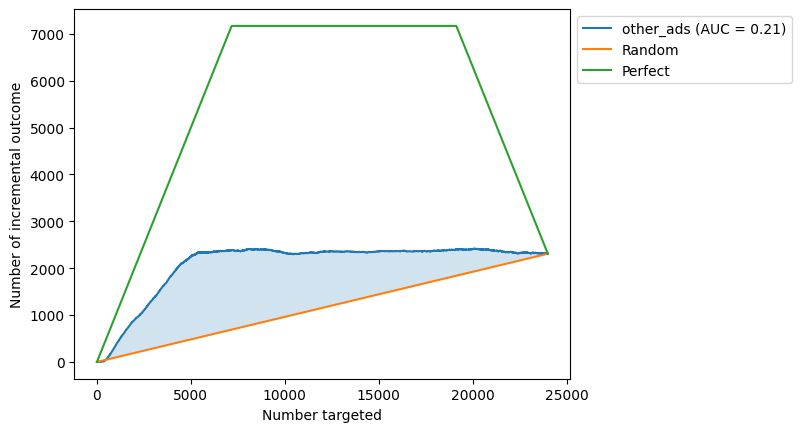

In [48]:
# sklift solomodel
plot_qini_curve(p_y_val, p_ul_sm2, p_treat_val, name="push")
plot_qini_curve(b_y_val, b_ul_sm2, b_treat_val, name="banner")
plot_qini_curve(oa_y_val, oa_ul_sm2, oa_treat_val, name="other_ads")

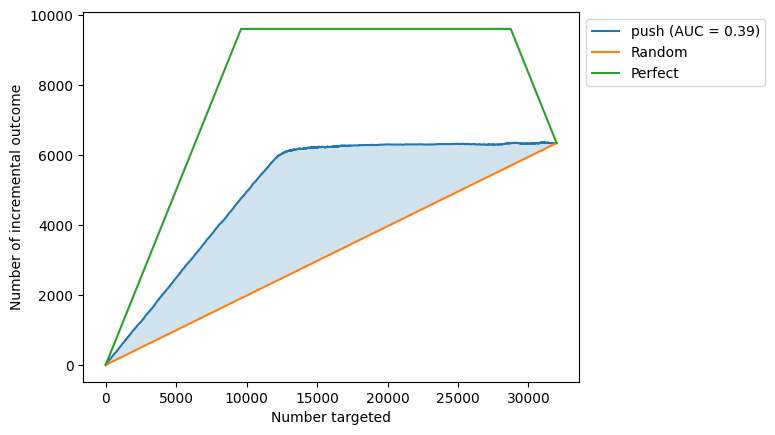

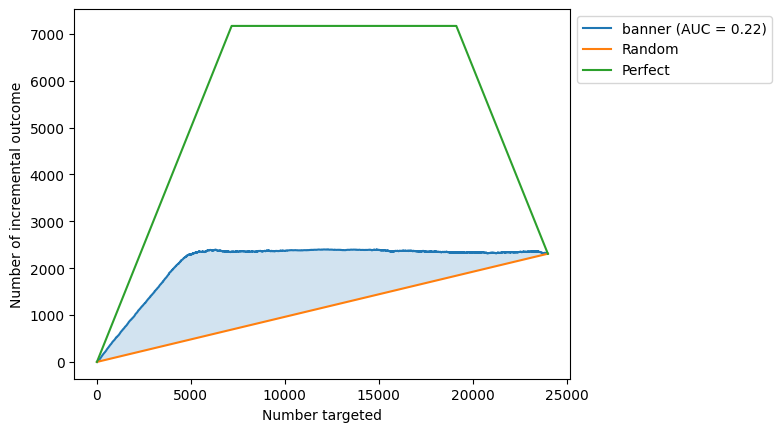

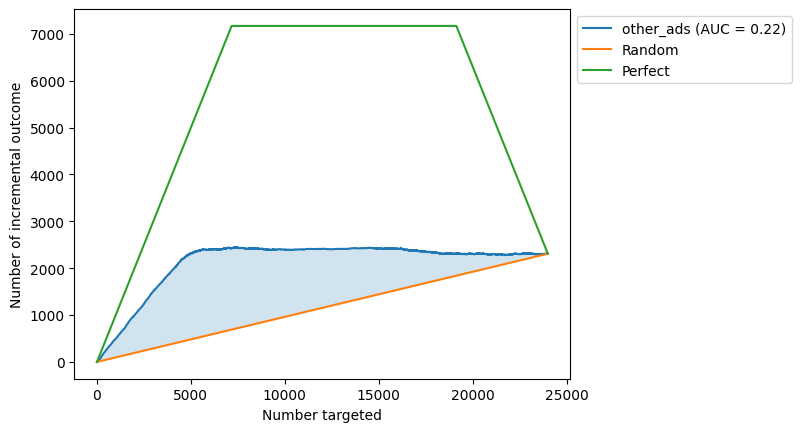

In [49]:
# sklift twomodel
plot_qini_curve(p_y_val, p_ul_tm1, p_treat_val, name="push")
plot_qini_curve(b_y_val, b_ul_tm1, b_treat_val, name="banner")
plot_qini_curve(oa_y_val, oa_ul_tm1, oa_treat_val, name="other_ads")

### Calibration

In [50]:
# push
p_X_tr_ = p_X_tr.copy()
p_X_tr_["t_flag"] = p_treat_tr
p_X_val_t = p_X_val.copy()
p_X_val_t["t_flag"] = 1
p_X_val_c = p_X_val.copy()
p_X_val_c["t_flag"] = 0

p_sm3 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
p_iso_t_sm3 = IsotonicRegression(out_of_bounds='clip')
p_iso_c_sm3 = IsotonicRegression(out_of_bounds='clip')

p_sm3.fit(p_X_tr_, p_y_tr)

p3_t_proba = p_sm3.predict_proba(p_X_val_t)[:, 1]
p3_c_proba = p_sm3.predict_proba(p_X_val_c)[:, 1]
p_iso_t_sm3.fit(p3_t_proba, p_y_val)
p_iso_c_sm3.fit(p3_c_proba, p_y_val)

p_sm3_calib_uplift = p_iso_t_sm3.transform(p3_t_proba) - p_iso_c_sm3.transform(p3_c_proba)
# banner
b_X_tr_ = b_X_tr.copy()
b_X_tr_["t_flag"] = b_treat_tr
b_X_val_t = b_X_val.copy()
b_X_val_t["t_flag"] = 1
b_X_val_c = b_X_val.copy()
b_X_val_c["t_flag"] = 0

b_sm3 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
b_iso_t_sm3 = IsotonicRegression(out_of_bounds='clip')
b_iso_c_sm3 = IsotonicRegression(out_of_bounds='clip')

b_sm3.fit(b_X_tr_, b_y_tr)

b3_t_proba = b_sm3.predict_proba(b_X_val_t)[:, 1]
b3_c_proba = b_sm3.predict_proba(b_X_val_c)[:, 1]
b_iso_t_sm3.fit(b3_t_proba, b_y_val)
b_iso_c_sm3.fit(b3_c_proba, b_y_val)

b_sm3_calib_uplift = b_iso_t_sm3.transform(b3_t_proba) - b_iso_c_sm3.transform(b3_c_proba)
# other_ads
oa_X_tr_ = oa_X_tr.copy()
oa_X_tr_["t_flag"] = oa_treat_tr
oa_X_val_t = oa_X_val.copy()
oa_X_val_t["t_flag"] = 1
oa_X_val_c = oa_X_val.copy()
oa_X_val_c["t_flag"] = 0

oa_sm3 = RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42)
oa_iso_t_sm3 = IsotonicRegression(out_of_bounds='clip')
oa_iso_c_sm3 = IsotonicRegression(out_of_bounds='clip')

oa_sm3.fit(oa_X_tr_, oa_y_tr)

oa3_t_proba = oa_sm3.predict_proba(oa_X_val_t)[:, 1]
oa3_c_proba = oa_sm3.predict_proba(oa_X_val_c)[:, 1]
oa_iso_t_sm3.fit(oa3_t_proba, oa_y_val)
oa_iso_c_sm3.fit(oa3_c_proba, oa_y_val)

oa_sm3_calib_uplift = oa_iso_t_sm3.transform(oa3_t_proba) - oa_iso_c_sm3.transform(oa3_c_proba)

In [51]:
p_auc_sm3_calib = round(qini_auc_score(p_y_val, p_sm3_calib_uplift, p_treat_val), 2)
b_auc_sm3_calib = round(qini_auc_score(b_y_val, b_sm3_calib_uplift, b_treat_val), 2)
oa_auc_sm3_calib = round(qini_auc_score(oa_y_val, oa_sm3_calib_uplift, oa_treat_val), 2)

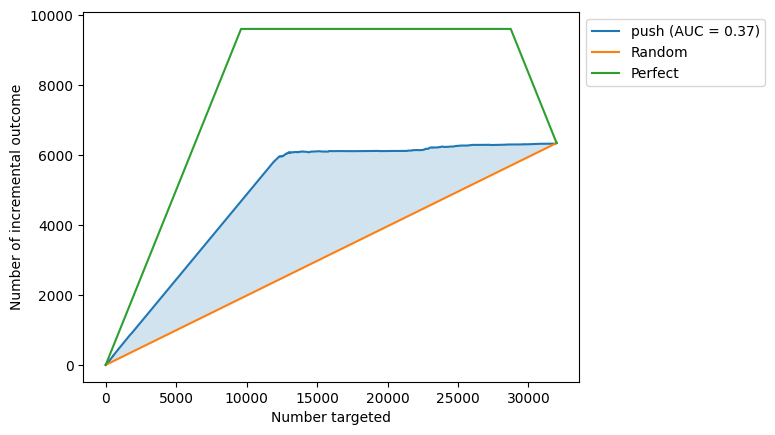

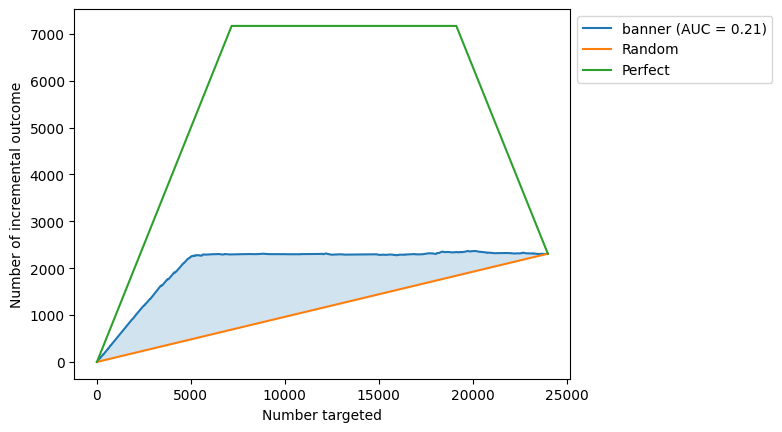

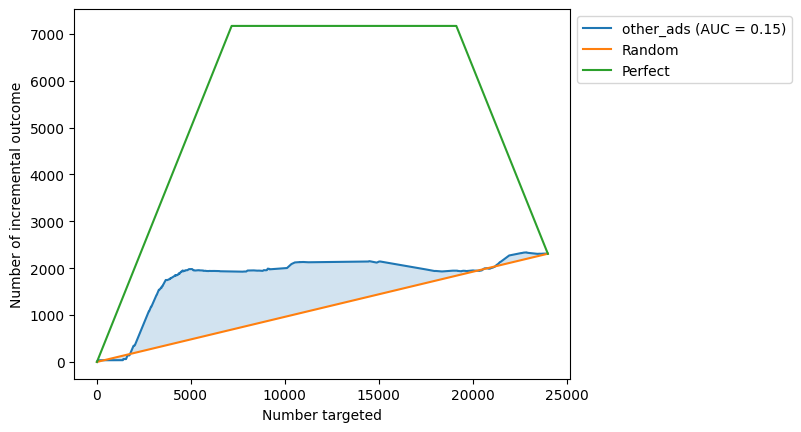

In [52]:
plot_qini_curve(p_y_val, p_sm3_calib_uplift, p_treat_val, name="push")
plot_qini_curve(b_y_val, b_sm3_calib_uplift, b_treat_val, name="banner")
plot_qini_curve(oa_y_val, oa_sm3_calib_uplift, oa_treat_val, name="other_ads")

# Finish

In [58]:
# push
p_X_tr_ = p_X_tr.copy()
p_X_val_ = p_X_val.copy()

p_tm2 = ClassTransformation(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
p_tm2.fit(X=p_X_tr_, y=p_y_tr, treatment=p_treat_tr)
p_ul_tm2 = p_tm2.predict(p_X_val_)
# banner
b_X_tr_ = b_X_tr.copy()
b_X_val_ = b_X_val.copy()

b_tm2 = ClassTransformation(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
b_tm2.fit(b_X_tr_, b_y_tr, b_treat_tr)
b_ul_tm2 = b_tm2.predict(b_X_val_)
# other_ads
oa_X_tr_ = oa_X_tr.copy()
oa_X_val_ = oa_X_val.copy()

oa_tm2 = ClassTransformation(RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42))
oa_tm2.fit(oa_X_tr_, oa_y_tr, oa_treat_tr)
oa_ul_tm2 = oa_tm1.predict(oa_X_val_)

In [59]:
p_auc_tm2_calib = round(qini_auc_score(p_y_val, p_ul_tm2, p_treat_val), 2)
b_auc_tm2_calib = round(qini_auc_score(b_y_val, b_ul_tm2, b_treat_val), 2)
oa_auc_tm2_calib = round(qini_auc_score(oa_y_val, oa_ul_tm2, oa_treat_val), 2)

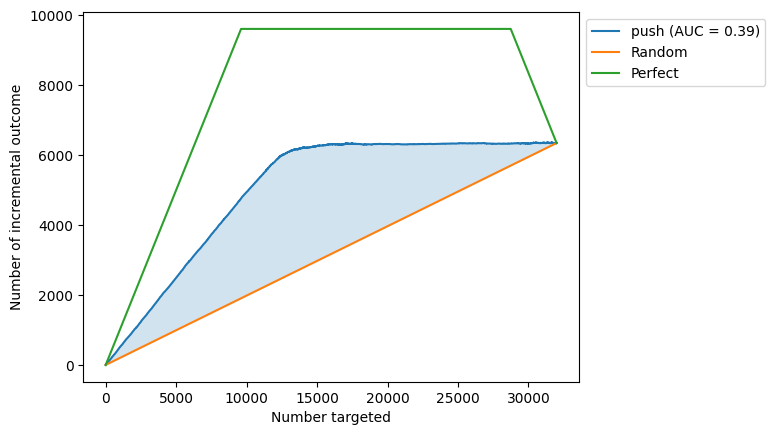

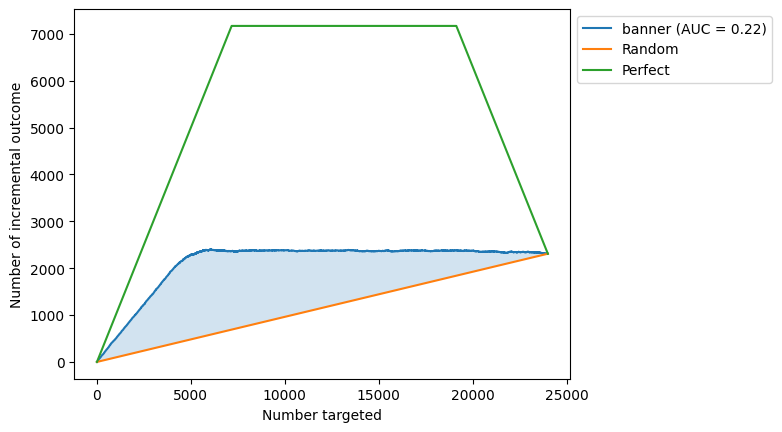

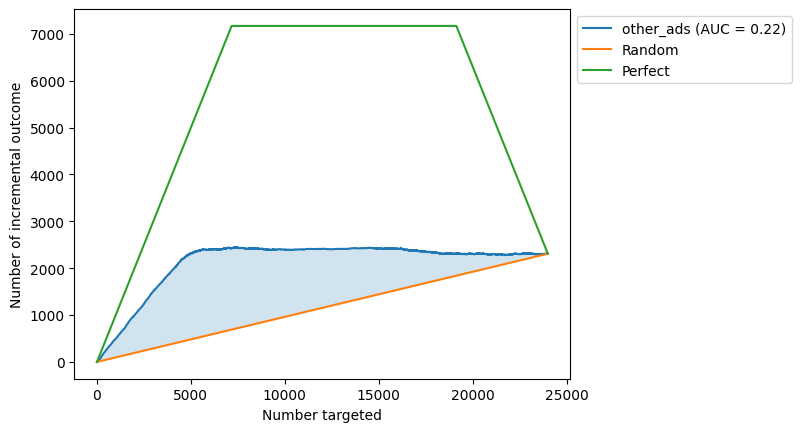

In [60]:
plot_qini_curve(p_y_val, p_ul_tm2, p_treat_val, name="push")
plot_qini_curve(b_y_val, b_ul_tm2, b_treat_val, name="banner")
plot_qini_curve(oa_y_val, oa_ul_tm2, oa_treat_val, name="other_ads")

## 4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [53]:
# ваш код здесь

### ваши выводы здесь